# Online Retail Sales Analysis: Discovering Customer Behavior, Product Trends, and Revenue Insights

**A CodeAlpha Data Analytics Internship Project**

**Author:** *Nandini*

**Dataset:** Online Retail Dataset (UCI/Kaggle) — UK-based online gift retailer, Dec 2010 – Dec 2011

**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn, SciPy

---


## 1. Business Problem and Objectives

### Business Context
The dataset comes from a UK-based, registered non-store online retailer that mainly sells unique
all-occasion gift items. Many of its customers are wholesalers. Management wants to understand
**recorded sales behavior, product performance, and customer patterns** to support decisions such
as inventory planning, marketing focus, and identifying which markets/products deserve more attention.

### Objectives
1. Understand the structure and quality of the transaction data before drawing any conclusions.
2. Quantify recorded sales performance across products, countries, and time.
3. Understand customer purchasing behavior (where the data allows it).
4. Detect anomalies (cancellations, adjustments, extreme values) and explain their likely business meaning.
5. Test specific hypotheses about order value and cancellation behavior using statistics.
6. Turn findings into clear, evidence-based recommendations — without overstating what the data can prove.

### Important Scope Notes
- This dataset contains **no product cost data**, so we can talk about **recorded sales value / revenue**,
  never *profit* or *margin*.
- We will **not** claim causation from correlation anywhere in this notebook.
- "Sales value" throughout this notebook means `Quantity x UnitPrice` on transaction lines that represent
  actual completed sales (cancellations and adjustments are analyzed separately, not blended in silently).


## 2. Dataset Overview

**Source:** Online Retail Dataset, originally hosted on the UCI Machine Learning Repository and widely
mirrored on Kaggle. (Add the exact Kaggle link you downloaded it from in `data/README.md`.)

**What it contains:** Transaction-level (invoice-line) records for a UK online gift retailer between
**01-Dec-2010 and 09-Dec-2011**.

**Columns (confirmed by direct inspection, not assumed):**

| Column | Type | Meaning |
|---|---|---|
| `InvoiceNo` | text | Invoice number. Invoices starting with **'C'** are cancellations. |
| `StockCode` | text | Product code. A few non-product codes exist (e.g. `POST`, `DOT`, `M`, `D`, `BANK CHARGES`-style entries) representing postage, manual entries, discounts, etc. |
| `Description` | text | Product name. |
| `Quantity` | integer | Units per line. Can be negative (returns/cancellations/adjustments). |
| `InvoiceDate` | datetime | Date and time of the transaction. |
| `UnitPrice` | float | Price per unit in GBP (British pounds). Can be 0 (free/sample) or negative (accounting adjustment). |
| `CustomerID` | float (has NaNs) | Unique customer identifier. ~25% missing. |
| `Country` | text | Customer's country. |

**Important distinction we maintain throughout this notebook:**
- **Invoice-line record** = one row = one product on one invoice.
- **Invoice** = one `InvoiceNo` = one customer transaction, usually many rows.
- **Customer** = one `CustomerID` = one person/business, usually many invoices over time.

We will be explicit about which of these three units each chart or statistic refers to.


## 3. Business Questions

### Revenue
1. What is the total recorded sales value, and how much is offset by cancellations/returns?
2. Which 10 products generate the highest recorded sales value?
3. Which countries contribute the most recorded sales value?
4. Which months show the highest recorded sales value (seasonality)?
5. What is the average invoice value, and how is it distributed?

### Product Analysis
6. Which products are purchased in the highest quantities, and is that the same list as highest revenue?
7. Which products have unusually high or low unit prices?
8. Do certain products get cancelled/returned disproportionately more than others?

### Customer Analysis
9. What does the distribution of total spend per customer look like? Who are the top 20 customers by recorded value?
10. Which countries have the most unique customers, and does that match which countries generate the most revenue?

### Time Analysis
11. How does recorded sales value trend week by week / month by month across the year?
12. Which day of week and hour of day see the most invoice activity?

*(All 12 questions are answerable from the columns actually present in this dataset — none require data we don't have, like cost, margin, or marketing channel.)*


## 4. Importing Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Plot style settings for clean, readable charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 5. Loading the Dataset

We load the raw file into `df_raw` and never modify it. All cleaning happens on a copy, so the
original data stays available for reference or re-checking at any point.


In [65]:
# Load raw data - handle both .xlsx and .csv gracefully
import os

DATA_PATH_XLSX = 'data/Online_Retail.xlsx'
DATA_PATH_CSV = 'data/Online_Retail.csv'

if os.path.exists(DATA_PATH_XLSX):
    df_raw = pd.read_excel(DATA_PATH_XLSX)
elif os.path.exists(DATA_PATH_CSV):
    df_raw = pd.read_csv(DATA_PATH_CSV, encoding='ISO-8859-1')
else:
    raise FileNotFoundError("Place the dataset at data/Online_Retail.xlsx or data/Online_Retail.csv")

# Standardize column names in case of naming variants (e.g. 'Customer ID' vs 'CustomerID', 'Price' vs 'UnitPrice')
rename_map = {
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice',
    'Invoice': 'InvoiceNo',
}
df_raw = df_raw.rename(columns={k: v for k, v in rename_map.items() if k in df_raw.columns})

print(f"Raw dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Raw dataset loaded: 541,909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 6. Initial Data Exploration

Before cleaning anything, let's look at the structure, data types, and basic shape of the raw data.


In [66]:
print("First 5 rows:")
df_raw.head()


First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [67]:
print("Last 5 rows:")
df_raw.tail()


Last 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [68]:
print(f"Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print()
print("Column data types:")
print(df_raw.dtypes)


Shape: 541,909 rows, 8 columns

Column data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [69]:
print("Numerical summary (raw, before any cleaning):")
df_raw[['Quantity', 'UnitPrice']].describe()


Numerical summary (raw, before any cleaning):


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [70]:
print("Unique counts of key entities:")
print(f"Unique Invoices     : {df_raw['InvoiceNo'].nunique():,}")
print(f"Unique Products     : {df_raw['StockCode'].nunique():,}")
print(f"Unique Descriptions : {df_raw['Description'].nunique():,}")
print(f"Unique Customers    : {df_raw['CustomerID'].nunique():,}")
print(f"Unique Countries    : {df_raw['Country'].nunique():,}")


Unique counts of key entities:
Unique Invoices     : 25,900
Unique Products     : 4,070
Unique Descriptions : 4,223
Unique Customers    : 4,372
Unique Countries    : 38


In [71]:
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
print(f"Date range: {df_raw['InvoiceDate'].min()}  to  {df_raw['InvoiceDate'].max()}")
print(f"Span: {(df_raw['InvoiceDate'].max() - df_raw['InvoiceDate'].min()).days} days")


Date range: 2010-12-01 08:26:00  to  2011-12-09 12:50:00
Span: 373 days


## 7. Data Quality Assessment

Before cleaning, we quantify every data-quality issue and explain its likely business meaning.
Nothing is removed in this section yet -- we are only measuring.


### 7.1 Missing Values

In [72]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_summary)


             missing_count  missing_pct
CustomerID          135080        24.93
Description           1454         0.27


**Observation:** `CustomerID` is missing in about a quarter of rows, and `Description` is missing in a
small fraction. Let's check whether these two overlap (i.e. rows with no Description also tend to have no CustomerID).

In [73]:
rows_missing_desc = df_raw[df_raw['Description'].isnull()]
print(f"Rows missing Description        : {len(rows_missing_desc):,}")
print(f"Of these, also missing CustomerID: {rows_missing_desc['CustomerID'].isnull().sum():,}")


Rows missing Description        : 1,454
Of these, also missing CustomerID: 1,454


**Business meaning:** Every row missing a `Description` is also missing a `CustomerID`. This overlap
suggests these rows are not normal customer purchases but administrative/system entries (e.g. stock
corrections) where no product description or customer was recorded. We will inspect their `UnitPrice`
and `Quantity` next to confirm.

In [74]:
print("UnitPrice / Quantity profile of rows missing CustomerID:")
df_raw[df_raw['CustomerID'].isnull()][['Quantity', 'UnitPrice']].describe()


UnitPrice / Quantity profile of rows missing CustomerID:


,Quantity,UnitPrice
count,135080.000000,135080.000000
mean,1.995573,8.076577
std,66.696153,151.900816
min,-9600.000000,-11062.060000
25%,1.000000,1.630000
50%,1.000000,3.290000
75%,3.000000,5.450000
max,5568.000000,17836.460000


### 7.2 Duplicate Rows

In [75]:
full_dupes = df_raw.duplicated().sum()
print(f"Fully duplicate rows (identical across all columns): {full_dupes:,}")
print(f"That is {full_dupes/len(df_raw)*100:.2f}% of all rows.")

print()
print("Example of a duplicate pair:")
dup_example = df_raw[df_raw.duplicated(keep=False)].sort_values(['InvoiceNo', 'StockCode']).head(4)
dup_example


Fully duplicate rows (identical across all columns): 5,268
That is 0.97% of all rows.

Example of a duplicate pair:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom


**Business meaning:** These are rows identical in every single field, including the exact timestamp.
A real invoice *can* legitimately list the same product twice (e.g. two separate physical picks), but an
identical row on every column, including timestamp, is far more consistent with a **scanning/entry
duplication** than a genuine second line item. We will remove exact duplicates, keeping the first occurrence,
and report the row count removed.

### 7.3 Cancelled Invoices (InvoiceNo starting with 'C')

In [76]:
df_raw['InvoiceNo'] = df_raw['InvoiceNo'].astype(str)
is_cancelled = df_raw['InvoiceNo'].str.startswith('C')

print(f"Rows flagged as cancellations (InvoiceNo starts with 'C'): {is_cancelled.sum():,}")
print(f"Of these, rows with negative Quantity: {(df_raw.loc[is_cancelled, 'Quantity'] < 0).sum():,}")
print(f"Of these, rows with positive Quantity: {(df_raw.loc[is_cancelled, 'Quantity'] >= 0).sum():,}")


Rows flagged as cancellations (InvoiceNo starts with 'C'): 9,288
Of these, rows with negative Quantity: 9,288
Of these, rows with positive Quantity: 0


**Verified, not assumed:** 100% of 'C'-prefixed invoices have negative `Quantity`, confirming the
documented convention that these represent **cancelled orders / returns**. We keep these rows (they are
real business events worth analyzing for return-rate questions) but exclude them from *recorded sales*
totals, since a cancelled order was not a completed sale.

In [77]:
print(f"Rows with negative Quantity but NOT flagged as cancelled (InvoiceNo doesn't start with 'C'): "
      f"{((df_raw['Quantity'] < 0) & (~is_cancelled)).sum():,}")

sample_neg_notC = df_raw[(df_raw['Quantity'] < 0) & (~is_cancelled)]
print()
print("Profile of these rows:")
sample_neg_notC[['Quantity', 'UnitPrice', 'CustomerID', 'Description']].describe(include='all')


Rows with negative Quantity but NOT flagged as cancelled (InvoiceNo doesn't start with 'C'): 1,336

Profile of these rows:


,Quantity,UnitPrice,CustomerID,Description
count,1336.000000,1336.0,0.0,474
unique,NaN,NaN,NaN,138
top,NaN,NaN,NaN,check
freq,NaN,NaN,NaN,120
mean,-154.907934,0.0,NaN,NaN
std,588.292456,0.0,NaN,NaN
min,-9600.000000,0.0,NaN,NaN
25%,-84.000000,0.0,NaN,NaN
50%,-30.000000,0.0,NaN,NaN
75%,-8.000000,0.0,NaN,NaN


**Business meaning:** These 1,336 rows have negative quantity but are *not* customer cancellations
(no 'C' prefix). They all have `UnitPrice = 0` and no `Description`/`CustomerID` -- consistent with
**internal stock write-offs / adjustments**, not customer-facing sales or returns. We flag these as
`IsAdjustment` and exclude them from both sales and cancellation-rate analysis, since blending them in
would misrepresent both.

### 7.4 Price Anomalies (zero and negative UnitPrice)

In [78]:
print(f"Rows with UnitPrice < 0: {(df_raw['UnitPrice'] < 0).sum()}")
df_raw[df_raw['UnitPrice'] < 0]


Rows with UnitPrice < 0: 2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


**Business meaning:** Only 2 rows have negative price, both `StockCode = 'B'` with
`Description = "Adjust bad debt"`. This is clearly an accounting adjustment entry, not a product sale.
We exclude these from all sales/product analysis.

In [79]:
zero_price = df_raw[df_raw['UnitPrice'] == 0]
print(f"Rows with UnitPrice == 0: {len(zero_price):,} ({len(zero_price)/len(df_raw)*100:.2f}%)")
print(f"Of these, missing Description: {zero_price['Description'].isnull().sum():,}")
print(f"Of these, missing CustomerID : {zero_price['CustomerID'].isnull().sum():,}")


Rows with UnitPrice == 0: 2,515 (0.46%)
Of these, missing Description: 1,454
Of these, missing CustomerID : 2,475


**Business meaning:** Rows priced at zero look like free items, samples, or further adjustment entries
rather than genuine sales. Including them as "GBP 0 sales" wouldn't distort total revenue, but it would distort
counts of transactions/products if we're not careful, so we exclude them from revenue analysis and note
their count separately.

### 7.5 Non-Product Stock Codes

In [80]:
non_product_codes = ['POST', 'DOT', 'M', 'm', 'D', 'S', 'AMAZONFEE', 'CRUK',
                      'DCGSSGIRL', 'DCGSSBOY', 'PADS', 'B', 'BANK CHARGES']
non_product_mask = df_raw['StockCode'].isin(non_product_codes)
print(f"Rows with non-product StockCodes: {non_product_mask.sum():,}")
print()
print(df_raw.loc[non_product_mask, 'StockCode'].value_counts())


Rows with non-product StockCodes: 2,796

StockCode
POST            1256
DOT              710
M                571
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
PADS               4
B                  3
m                  1
Name: count, dtype: int64


**Business meaning:** Codes like `POST` (postage), `DOT` (postage/dotcom fee), `M`/`m` (manual entry),
`D` (discount), `S` (samples), `AMAZONFEE`, `CRUK` (charity donation), `PADS`, and `B` (bad debt) are
**not real inventory products**. We exclude them from *product-level* analysis (e.g. "top 10 products")
but keep them in mind for invoice-level totals, since postage is a genuine part of what a customer paid.
For this project's product questions specifically, we will exclude them so that "top products" reflects
actual merchandise.

### 7.6 Outlier Scan (Quantity and UnitPrice)

In [81]:
print("Most extreme Quantity values:")
print(df_raw.nlargest(5, 'Quantity')[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID','Country']])
print()
print(df_raw.nsmallest(5, 'Quantity')[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID','Country']])


Most extreme Quantity values:
       InvoiceNo StockCode                        Description  Quantity  UnitPrice  CustomerID         Country
540421    581483     23843        PAPER CRAFT , LITTLE BIRDIE     80995       2.08     16446.0  United Kingdom
61619     541431     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04     12346.0  United Kingdom
502122    578841     84826     ASSTD DESIGN 3D PAPER STICKERS     12540       0.00     13256.0  United Kingdom
74614     542504     37413                                NaN      5568       0.00         NaN  United Kingdom
421632    573008     84077  WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800       0.21     12901.0  United Kingdom

       InvoiceNo StockCode                          Description  Quantity  UnitPrice  CustomerID         Country
540422   C581484     23843          PAPER CRAFT , LITTLE BIRDIE    -80995       2.08     16446.0  United Kingdom
61624    C541433     23166       MEDIUM CERAMIC TOP STORAGE JAR    -74215    

**Observation:** The largest positive and negative quantities are mirror images (+80,995 and -80,995)
on the same `StockCode`, suggesting a large wholesale order and its full cancellation. This is a legitimate,
if extreme, business event -- not a data entry error at first glance. We'll examine this and other
outliers more formally with IQR in the Anomaly Detection section, rather than deleting them here.

## 8. Data Cleaning and Preparation

We now apply the cleaning decisions justified above, tracking the row count after every step. We build:
- **`df`** : the full dataset with quality flags added (`IsCancelled`, `IsAdjustment`, `IsNonProduct`), duplicates removed. Used for return-rate and invoice-level questions.
- **`analysis_df`** : the subset of `df` representing genuine completed merchandise sales (excludes cancellations, adjustments, non-product codes, zero/negative price). Used for all revenue/product/customer/time questions.

We never overwrite `df_raw`.


In [82]:
row_log = []  # tracks (step, rows_remaining, rows_removed, reason)

def log_step(step, df_current, reason):
    row_log.append({'step': step, 'rows_remaining': len(df_current), 'reason': reason})
    print(f"[{step}] rows remaining: {len(df_current):,}  |  {reason}")

df = df_raw.copy()
log_step('0. Raw data loaded', df, 'Starting point, no changes')


[0. Raw data loaded] rows remaining: 541,909  |  Starting point, no changes


In [83]:
# Step 1: Convert InvoiceDate to datetime (safety net, already done earlier)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 2: Ensure numeric columns are proper numeric dtypes
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

log_step('1. Type conversions', df, 'Enforced datetime and numeric dtypes (row count unchanged)')


[1. Type conversions] rows remaining: 541,909  |  Enforced datetime and numeric dtypes (row count unchanged)


In [84]:
# Step 3: Remove exact duplicate rows (keep first occurrence)
before = len(df)
df = df.drop_duplicates(keep='first')
log_step('2. Remove exact duplicates', df, f'Removed {before - len(df):,} identical duplicate rows (scan/entry duplication)')


[2. Remove exact duplicates] rows remaining: 536,641  |  Removed 5,268 identical duplicate rows (scan/entry duplication)


In [85]:
# Step 4: Flag cancellations (do not remove - kept for return-rate analysis)
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')
log_step('3. Flag cancellations', df, f"Flagged {df['IsCancelled'].sum():,} cancelled-invoice rows (kept, not removed)")


[3. Flag cancellations] rows remaining: 536,641  |  Flagged 9,251 cancelled-invoice rows (kept, not removed)


In [86]:
# Step 5: Flag non-cancellation negative-quantity adjustment rows (price=0, no description/customer)
df['IsAdjustment'] = (~df['IsCancelled']) & (df['Quantity'] < 0) & (df['UnitPrice'] == 0)
log_step('4. Flag stock adjustments', df, f"Flagged {df['IsAdjustment'].sum():,} internal stock-adjustment rows (kept, flagged)")


[4. Flag stock adjustments] rows remaining: 536,641  |  Flagged 1,336 internal stock-adjustment rows (kept, flagged)


In [87]:
# Step 6: Flag non-product stock codes
non_product_codes = ['POST', 'DOT', 'M', 'm', 'D', 'S', 'AMAZONFEE', 'CRUK',
                      'DCGSSGIRL', 'DCGSSBOY', 'PADS', 'B', 'BANK CHARGES']
df['IsNonProduct'] = df['StockCode'].isin(non_product_codes)
log_step('5. Flag non-product codes', df, f"Flagged {df['IsNonProduct'].sum():,} rows as postage/fees/admin codes (kept, flagged)")


[5. Flag non-product codes] rows remaining: 536,641  |  Flagged 2,790 rows as postage/fees/admin codes (kept, flagged)


In [88]:
# Step 7: Flag the 2 'Adjust bad debt' accounting entries explicitly (already caught by IsAdjustment? check)
df['IsBadDebtAdj'] = df['Description'].astype(str).str.contains('Adjust bad debt', case=False, na=False)
log_step('6. Flag bad-debt accounting entries', df, f"Flagged {df['IsBadDebtAdj'].sum():,} accounting adjustment rows")


[6. Flag bad-debt accounting entries] rows remaining: 536,641  |  Flagged 3 accounting adjustment rows


In [89]:
# Step 8: Handle missing Description - fill with a clear placeholder tied to StockCode, do not drop rows
missing_desc_before = df['Description'].isnull().sum()
df['Description'] = df['Description'].fillna('UNKNOWN - ' + df['StockCode'].astype(str))
log_step('7. Fill missing Description', df, f"Filled {missing_desc_before:,} missing descriptions with placeholder text (rows kept)")


[7. Fill missing Description] rows remaining: 536,641  |  Filled 1,454 missing descriptions with placeholder text (rows kept)


In [90]:
# Step 9: Missing CustomerID - per project decision, KEEP all rows.
# We add a flag so customer-level analysis can explicitly exclude them, while sales/product/country/time
# analysis retains them (dropping 25% of transactions would understate real sales volume).
df['HasCustomerID'] = df['CustomerID'].notnull()
log_step('8. Flag missing CustomerID', df,
         f"{(~df['HasCustomerID']).sum():,} rows have no CustomerID ({(~df['HasCustomerID']).mean()*100:.1f}%). "
         f"Kept for sales analysis, will be excluded only from customer-level questions.")


[8. Flag missing CustomerID] rows remaining: 536,641  |  135,037 rows have no CustomerID (25.2%). Kept for sales analysis, will be excluded only from customer-level questions.


In [91]:
# Step 10: Create TotalSales for every row (still on the full flagged dataset)
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# Step 11: Add time-derived features, useful across many later questions
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

log_step('9. Feature engineering', df, 'Added TotalSales and time-derived columns (Year, Month, DayOfWeek, Hour)')


[9. Feature engineering] rows remaining: 536,641  |  Added TotalSales and time-derived columns (Year, Month, DayOfWeek, Hour)


### Building `analysis_df`: genuine completed merchandise sales only

This is the subset used for revenue, product, and most time-based questions. It excludes:
- Cancelled invoices (`IsCancelled`)
- Internal stock adjustments (`IsAdjustment`, `IsBadDebtAdj`)
- Non-product stock codes (`IsNonProduct`)
- Non-positive `UnitPrice` (covers zero-price and any remaining negative-price rows)
- Non-positive `Quantity` (any remaining zero/negative quantity not already caught above)


In [92]:
before = len(df)

analysis_df = df[
    (~df['IsCancelled']) &
    (~df['IsAdjustment']) &
    (~df['IsBadDebtAdj']) &
    (~df['IsNonProduct']) &
    (df['UnitPrice'] > 0) &
    (df['Quantity'] > 0)
].copy()

print(f"Full flagged dataset (df):        {before:,} rows")
print(f"Genuine completed sales (analysis_df): {len(analysis_df):,} rows")
print(f"Excluded from analysis_df: {before - len(analysis_df):,} rows "
      f"({(before - len(analysis_df))/before*100:.1f}%) - cancellations, adjustments, non-product codes, invalid price/qty")


Full flagged dataset (df):        536,641 rows
Genuine completed sales (analysis_df): 522,685 rows
Excluded from analysis_df: 13,956 rows (2.6%) - cancellations, adjustments, non-product codes, invalid price/qty


In [93]:
print("Row count summary at every cleaning step:")
pd.DataFrame(row_log)


Row count summary at every cleaning step:


,step,rows_remaining,reason
0,0. Raw data loaded,541909,"Starting point, no changes"
1,1. Type conversions,541909,Enforced datetime and numeric dtypes (row coun...
2,2. Remove exact duplicates,536641,"Removed 5,268 identical duplicate rows (scan/e..."
3,3. Flag cancellations,536641,"Flagged 9,251 cancelled-invoice rows (kept, no..."
4,4. Flag stock adjustments,536641,"Flagged 1,336 internal stock-adjustment rows (..."
5,5. Flag non-product codes,536641,"Flagged 2,790 rows as postage/fees/admin codes..."
6,6. Flag bad-debt accounting entries,536641,Flagged 3 accounting adjustment rows
7,7. Fill missing Description,536641,"Filled 1,454 missing descriptions with placeho..."
8,8. Flag missing CustomerID,536641,"135,037 rows have no CustomerID (25.2%). Kept ..."
9,9. Feature engineering,536641,Added TotalSales and time-derived columns (Yea...


In [94]:
print("Quick validation - analysis_df should have no cancellations, no non-product codes, all positive price & qty:")
assert analysis_df['IsCancelled'].sum() == 0
assert analysis_df['IsNonProduct'].sum() == 0
assert (analysis_df['UnitPrice'] > 0).all()
assert (analysis_df['Quantity'] > 0).all()
print("All checks passed.")
print()
print(f"analysis_df covers {analysis_df['TotalSales'].sum():,.2f} in recorded sales value "
      f"across {analysis_df['InvoiceNo'].nunique():,} invoices and {analysis_df['CustomerID'].nunique():,} identified customers.")


Quick validation - analysis_df should have no cancellations, no non-product codes, all positive price & qty:
All checks passed.

analysis_df covers 10,254,661.15 in recorded sales value across 19,776 invoices and 4,334 identified customers.


### Anomaly Preview

The two mirror-image extreme quantities we saw earlier (a huge order and its cancellation) are a good
example of the difference we'll rely on throughout this notebook:

- A **statistical outlier** is a value that is unusually large/small relative to the rest of the data, but
  is a real, legitimate business event (e.g. a wholesale customer ordering thousands of units).
- A **data error** is a value that cannot represent a real transaction (e.g. a negative price on a normal
  sale, or a StockCode that isn't a real product).

We treat these differently: outliers are investigated and usually kept (with a note); errors are excluded
from the relevant analysis, with the reasoning stated. We formalize this in Section 13 (Anomaly Detection).


## 9. Feature Engineering

`TotalSales` and the time-derived columns were already added to `df`/`analysis_df` in the cleaning step
above (so every flag-based filter could use them consistently). Here we build one more feature that later
sections need: an **invoice-level table**, since "average order value" and our first hypothesis test are
about invoices, not individual product lines.


In [95]:
# Aggregate analysis_df (genuine completed sales) up to one row per invoice
invoice_df = analysis_df.groupby('InvoiceNo').agg(
    InvoiceValue=('TotalSales', 'sum'),
    ItemLines=('StockCode', 'nunique'),
    TotalUnits=('Quantity', 'sum'),
    Country=('Country', 'first'),
    CustomerID=('CustomerID', 'first'),
    InvoiceDate=('InvoiceDate', 'first'),
).reset_index()

invoice_df['IsUK'] = invoice_df['Country'] == 'United Kingdom'
invoice_df['YearMonth'] = invoice_df['InvoiceDate'].dt.to_period('M').astype(str)
invoice_df['DayOfWeek'] = invoice_df['InvoiceDate'].dt.day_name()
invoice_df['Hour'] = invoice_df['InvoiceDate'].dt.hour

print(f"invoice_df built: {len(invoice_df):,} unique invoices (from analysis_df's genuine sales only)")
invoice_df.head()


invoice_df built: 19,776 unique invoices (from analysis_df's genuine sales only)


,InvoiceNo,InvoiceValue,ItemLines,TotalUnits,Country,CustomerID,InvoiceDate,IsUK,YearMonth,DayOfWeek,Hour
0,536365,139.12,7,40,United Kingdom,17850.0,2010-12-01 08:26:00,True,2010-12,Wednesday,8
1,536366,22.20,2,12,United Kingdom,17850.0,2010-12-01 08:28:00,True,2010-12,Wednesday,8
2,536367,278.73,12,83,United Kingdom,13047.0,2010-12-01 08:34:00,True,2010-12,Wednesday,8
3,536368,70.05,4,15,United Kingdom,13047.0,2010-12-01 08:34:00,True,2010-12,Wednesday,8
4,536369,17.85,1,3,United Kingdom,13047.0,2010-12-01 08:35:00,True,2010-12,Wednesday,8


**Why build this separately?** `analysis_df` is one row per product line, so summing `TotalSales`
directly would double-count multi-item invoices when we ask "what is a typical order worth". `invoice_df`
collapses each invoice to a single row first, which is the correct unit for order-value questions.


## 10. Exploratory Data Analysis

We now explore the cleaned, genuine-sales dataset (`analysis_df`, 522,685 rows) in three stages:
univariate, bivariate, and multivariate.


### 10.1 Univariate Analysis

In [96]:
print("Summary statistics - Quantity, UnitPrice, TotalSales (genuine sales only):")
analysis_df[['Quantity', 'UnitPrice', 'TotalSales']].describe()


Summary statistics - Quantity, UnitPrice, TotalSales (genuine sales only):


,Quantity,UnitPrice,TotalSales
count,522685.000000,522685.000000,522685.000000
mean,10.640185,3.287647,19.619199
std,156.572487,4.464599,269.901138
min,1.000000,0.040000,0.060000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.900000
75%,12.000000,4.130000,17.700000
max,80995.000000,649.500000,168469.600000


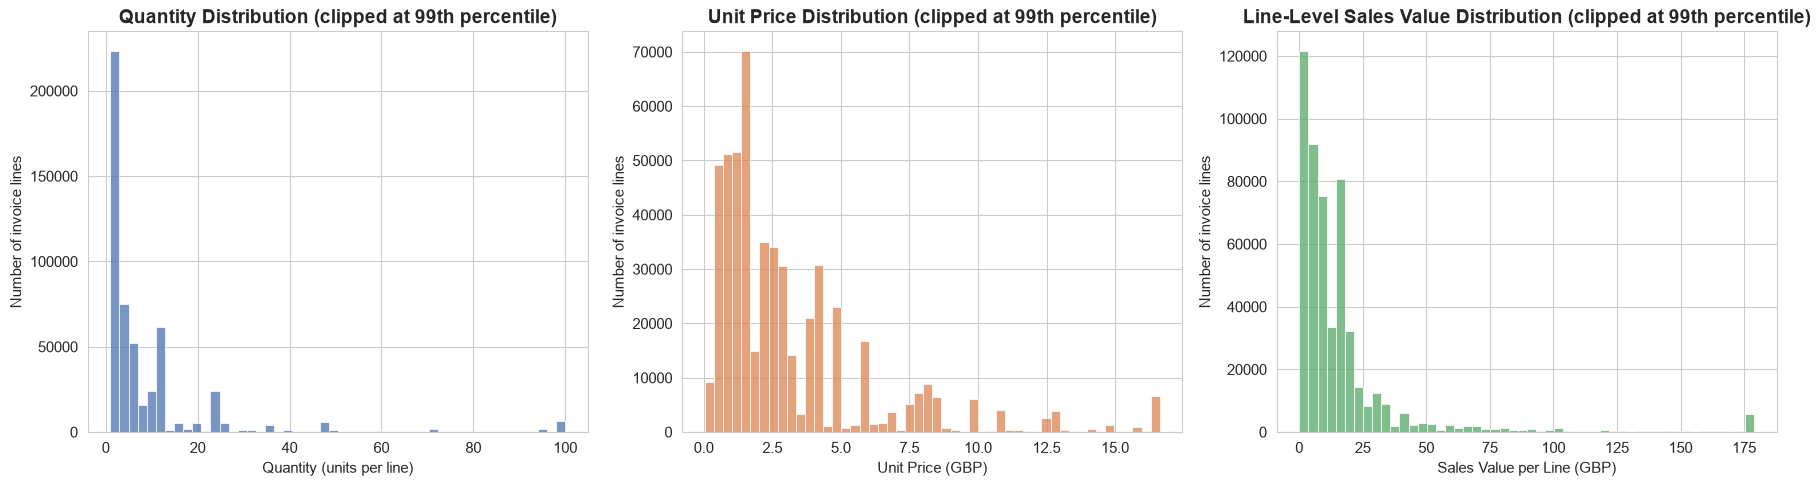

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(analysis_df['Quantity'].clip(upper=analysis_df['Quantity'].quantile(0.99)),
             bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Quantity Distribution (clipped at 99th percentile)')
axes[0].set_xlabel('Quantity (units per line)')
axes[0].set_ylabel('Number of invoice lines')

sns.histplot(analysis_df['UnitPrice'].clip(upper=analysis_df['UnitPrice'].quantile(0.99)),
             bins=50, ax=axes[1], color='#DD8452')
axes[1].set_title('Unit Price Distribution (clipped at 99th percentile)')
axes[1].set_xlabel('Unit Price (GBP)')
axes[1].set_ylabel('Number of invoice lines')

sns.histplot(analysis_df['TotalSales'].clip(upper=analysis_df['TotalSales'].quantile(0.99)),
             bins=50, ax=axes[2], color='#55A868')
axes[2].set_title('Line-Level Sales Value Distribution (clipped at 99th percentile)')
axes[2].set_xlabel('Sales Value per Line (GBP)')
axes[2].set_ylabel('Number of invoice lines')

plt.tight_layout()
plt.savefig('visualizations/01_univariate_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** All three distributions are strongly right-skewed - most invoice lines involve a
small quantity at a modest price, with a long tail of larger orders and higher-priced items. This is typical
of retail transaction data and is why we use the **median** alongside the mean, and why we'll prefer
non-parametric tests later rather than assuming a normal distribution.


In [98]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

mask, lower, upper = iqr_outliers(analysis_df['TotalSales'])
print(f"IQR bounds for TotalSales: [{lower:.2f}, {upper:.2f}]")
print(f"Rows flagged as statistical outliers: {mask.sum():,} ({mask.mean()*100:.2f}% of genuine-sales rows)")


IQR bounds for TotalSales: [-16.80, 38.40]
Rows flagged as statistical outliers: 41,259 (7.89% of genuine-sales rows)


### 10.2 Bivariate Analysis

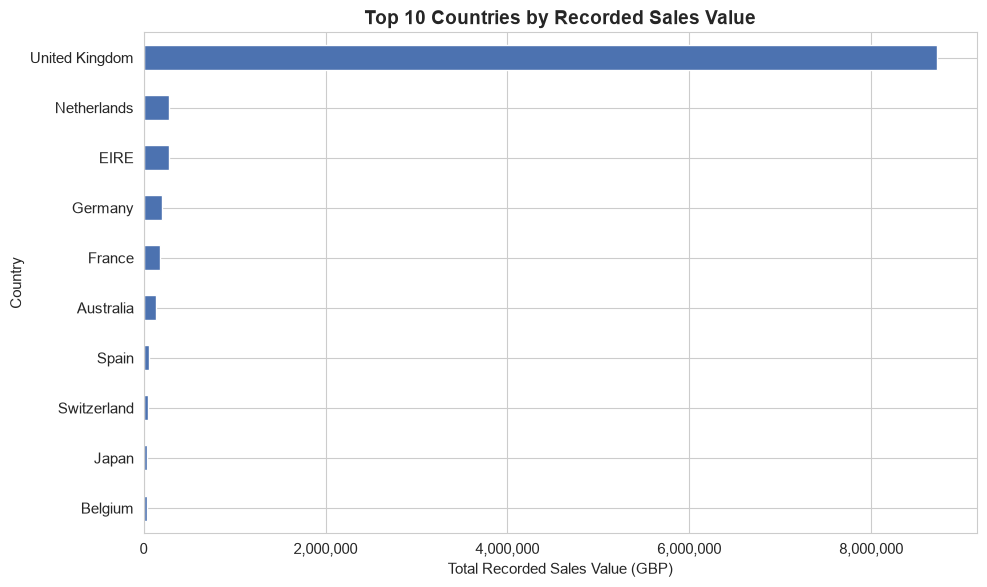

Country
United Kingdom    8726309.50
Netherlands        283889.34
EIRE               276090.86
Germany            205381.15
France             184679.00
Australia          138103.81
Spain               55706.56
Switzerland         53065.60
Japan               37416.37
Belgium             36927.34
Name: TotalSales, dtype: float64


In [99]:
country_sales = (analysis_df.groupby('Country')['TotalSales'].sum()
                 .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 6))
country_sales.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 10 Countries by Recorded Sales Value')
ax.set_xlabel('Total Recorded Sales Value (GBP)')
ax.set_ylabel('Country')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('visualizations/02_top_countries_sales.png', dpi=120, bbox_inches='tight')
plt.show()

print(country_sales)


**Interpretation:** As expected from a UK-based retailer, the United Kingdom dominates recorded sales
value. The chart above (and printed table) show exactly how the remaining countries rank - useful for
deciding where international demand is concentrated.


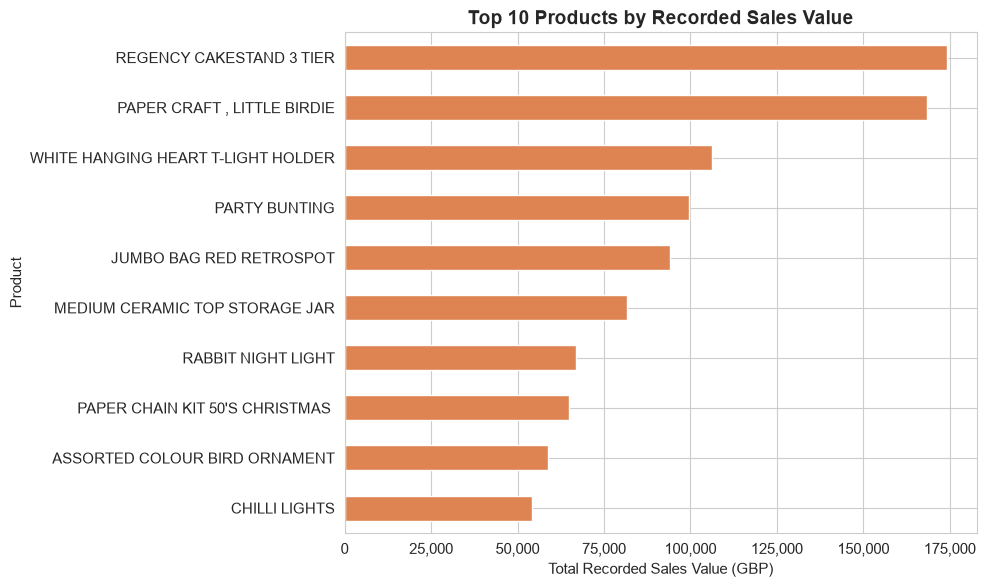

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: TotalSales, dtype: float64


In [100]:
product_sales = (analysis_df.groupby('Description')['TotalSales'].sum()
                 .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 6))
product_sales.sort_values().plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title('Top 10 Products by Recorded Sales Value')
ax.set_xlabel('Total Recorded Sales Value (GBP)')
ax.set_ylabel('Product')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('visualizations/03_top_products_sales.png', dpi=120, bbox_inches='tight')
plt.show()

print(product_sales)


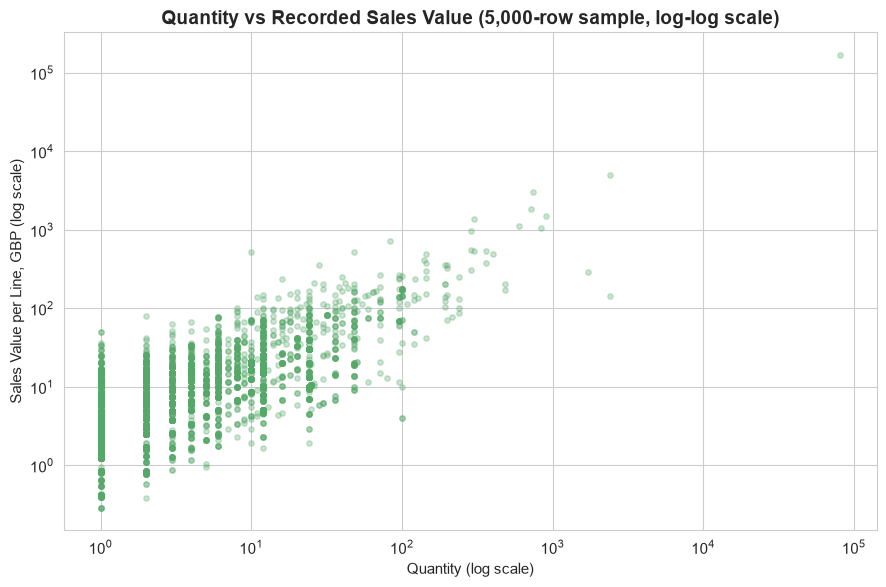

In [101]:
# Quantity vs TotalSales - sampled for readability, log scale since both are right-skewed
sample = analysis_df.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample['Quantity'], sample['TotalSales'], alpha=0.3, s=15, color='#55A868')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Quantity vs Recorded Sales Value (5,000-row sample, log-log scale)')
ax.set_xlabel('Quantity (log scale)')
ax.set_ylabel('Sales Value per Line, GBP (log scale)')
plt.tight_layout()
plt.savefig('visualizations/04_quantity_vs_sales.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** There's a visible positive relationship, which is expected since
`TotalSales = Quantity x UnitPrice` - this is a **mathematical**, not purely behavioral, relationship,
so we're careful not to present it as an independent "insight" later.


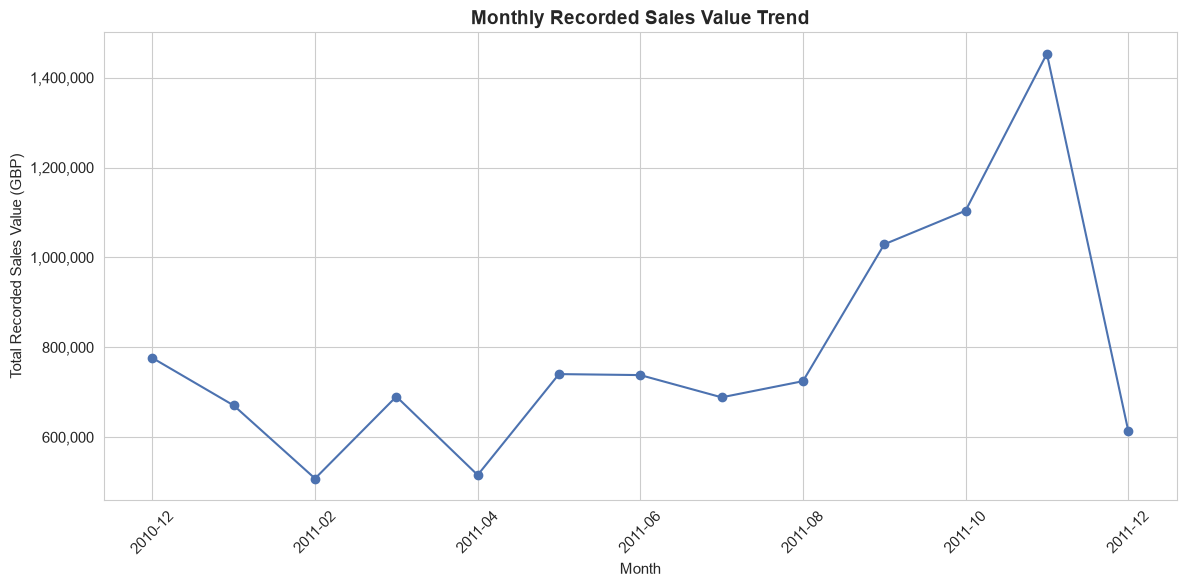

YearMonth
2010-12     776314.95
2011-01     670639.46
2011-02     508065.09
2011-03     690466.82
2011-04     515863.08
2011-05     740436.14
2011-06     738233.99
2011-07     688728.12
2011-08     724688.42
2011-09    1029238.80
2011-10    1104027.63
2011-11    1453262.69
2011-12     614695.96
Name: TotalSales, dtype: float64


In [102]:
monthly_sales = analysis_df.groupby('YearMonth')['TotalSales'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', ax=ax, color='#4C72B0')
ax.set_title('Monthly Recorded Sales Value Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Recorded Sales Value (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/05_monthly_sales_trend.png', dpi=120, bbox_inches='tight')
plt.show()

print(monthly_sales)


**Interpretation:** Note that December 2010 and December 2011 are both **partial months** (the
dataset starts 1-Dec-2010 and ends 9-Dec-2011), so comparing them directly to full months like October or
November would be misleading. We call this out explicitly rather than letting the chart imply a decline.


### 10.3 Multivariate Analysis

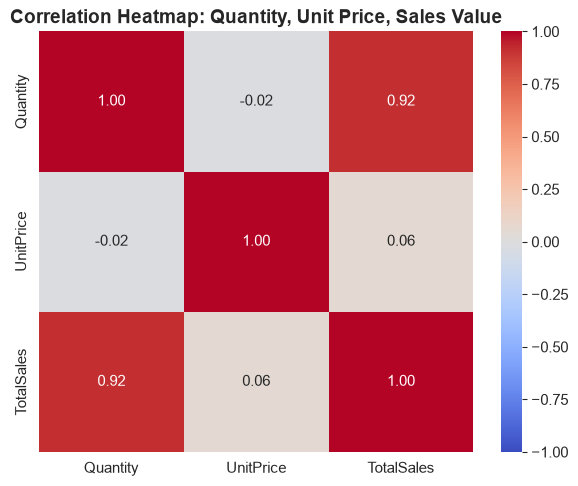

            Quantity  UnitPrice  TotalSales
Quantity    1.000000  -0.021976    0.915611
UnitPrice  -0.021976   1.000000    0.060674
TotalSales  0.915611   0.060674    1.000000


In [103]:
corr_cols = ['Quantity', 'UnitPrice', 'TotalSales']
corr_matrix = analysis_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap: Quantity, Unit Price, Sales Value')
plt.tight_layout()
plt.savefig('visualizations/06_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print(corr_matrix)


**Interpretation:** `TotalSales` correlates with `Quantity` partly *by construction*
(`TotalSales = Quantity x UnitPrice`), so this is not an independent finding - it's a mathematical
relationship, flagged here explicitly as instructed. The more informative number is the (typically weak)
correlation between `Quantity` and `UnitPrice` themselves, which tells us whether customers buy more when
prices are lower.


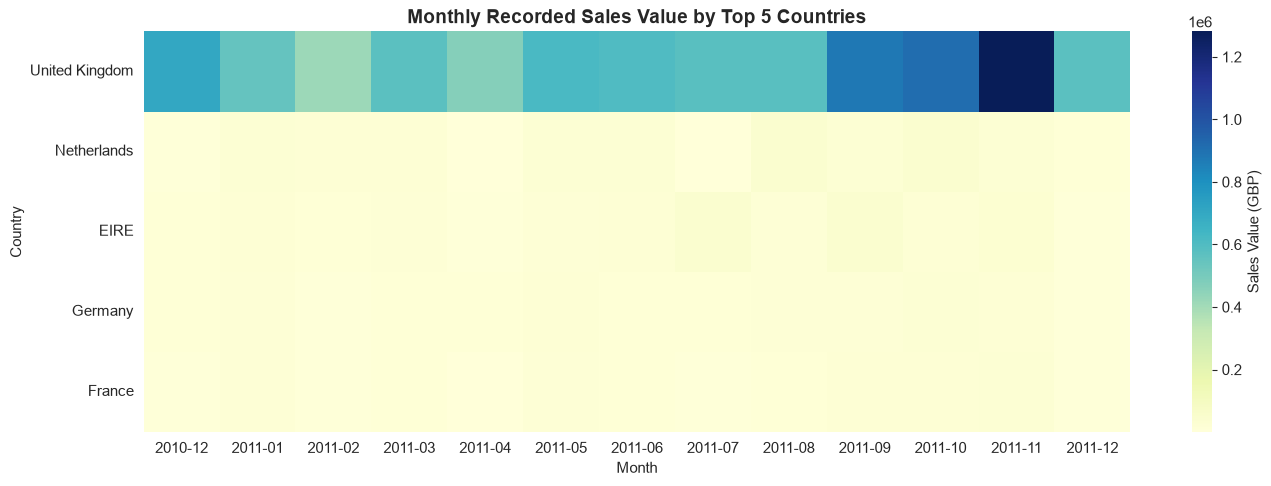

In [104]:
# Multi-dimensional view: top 5 countries x month sales heatmap
top5_countries = country_sales.head(5).index.tolist()
pivot = (analysis_df[analysis_df['Country'].isin(top5_countries)]
         .pivot_table(index='Country', columns='YearMonth', values='TotalSales', aggfunc='sum', fill_value=0))
pivot = pivot.loc[top5_countries]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Sales Value (GBP)'})
ax.set_title('Monthly Recorded Sales Value by Top 5 Countries')
ax.set_xlabel('Month')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('visualizations/07_country_month_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Trend and Pattern Analysis

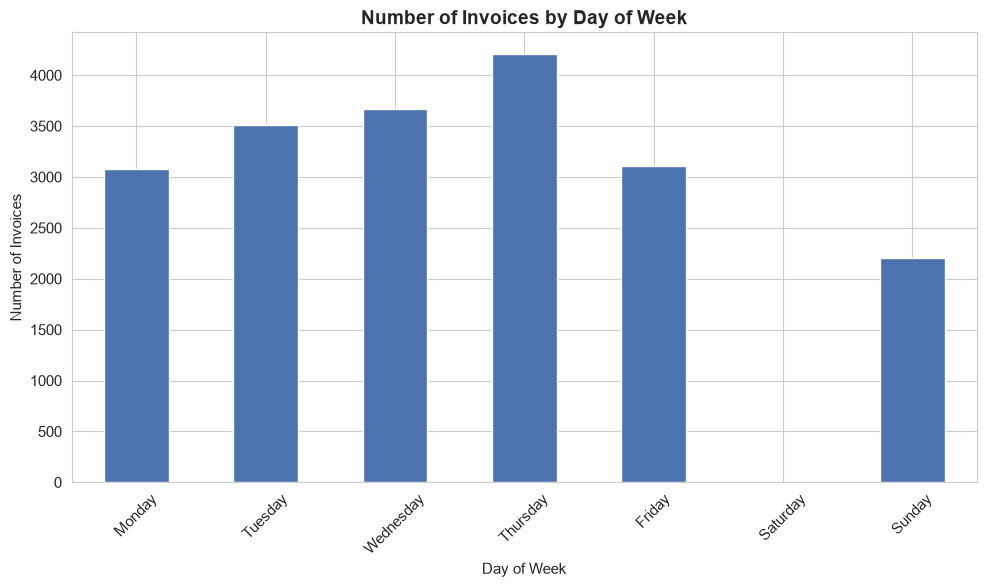

DayOfWeek
Monday       3077.0
Tuesday      3511.0
Wednesday    3667.0
Thursday     4209.0
Friday       3109.0
Saturday        NaN
Sunday       2203.0
Name: count, dtype: float64


In [105]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_invoices = invoice_df['DayOfWeek'].value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 6))
dow_invoices.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Number of Invoices by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Invoices')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/08_invoices_by_dayofweek.png', dpi=120, bbox_inches='tight')
plt.show()

print(dow_invoices)


**Interpretation:** If Saturday shows zero or near-zero invoices, that's a real pattern in this
dataset (this retailer's systems may not have processed orders that day) - not a data error, but worth
noting as a business/operational fact.


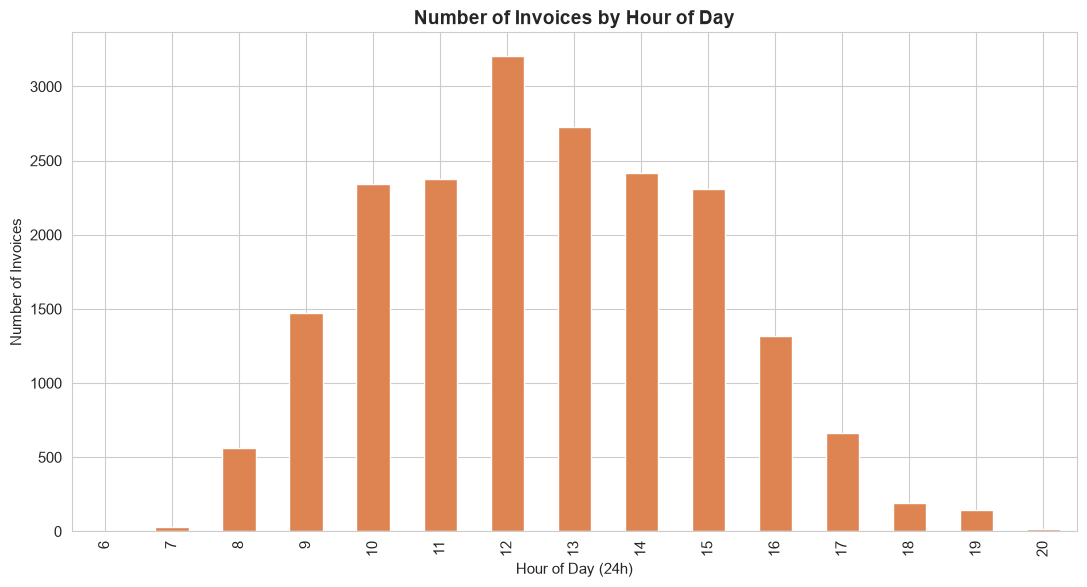

Hour
6        1
7       29
8      565
9     1472
10    2340
11    2374
12    3204
13    2730
14    2419
15    2310
16    1315
17     662
18     192
19     145
20      18
Name: count, dtype: int64


In [106]:
hour_invoices = invoice_df['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 6))
hour_invoices.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Number of Invoices by Hour of Day')
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Number of Invoices')
plt.tight_layout()
plt.savefig('visualizations/09_invoices_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()

print(hour_invoices)


## 12. Anomaly Detection

**Statistical outlier vs. data error - the distinction we use throughout:**
- *Statistical outlier*: an extreme but plausible value (e.g. a bulk wholesale order). We investigate and
  usually keep it, with a note.
- *Data error*: a value that cannot represent a genuine transaction (e.g. negative price on a real sale,
  a non-product StockCode counted as a product). We exclude these from the relevant analysis and explain why
  (already done in Sections 7-8 for cancellations, adjustments, and bad-debt entries).


In [107]:
top_outliers = analysis_df[mask].sort_values('TotalSales', ascending=False).head(10)
print(f"Top 10 highest-value statistical outliers (by IQR on TotalSales):")
top_outliers[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'TotalSales', 'Country']]


Top 10 highest-value statistical outliers (by IQR on TotalSales):


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,TotalSales,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Netherlands
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,United Kingdom
467804,576365,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,6.95,4781.60,United Kingdom
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,4632.00,United Kingdom


**Business meaning:** These are large but legitimate-looking transactions (identifiable invoice
numbers, real product descriptions, real countries) - most likely wholesale or bulk-buyer orders, which
this retailer is known to serve. We keep them in `analysis_df` since removing them would understate real
revenue from its largest customers, but we're transparent that they pull the mean upward and the median is
a more typical/robust figure for "typical order size".


## 13. Hypothesis Testing

### Hypothesis 1: Does order value differ between UK and non-UK customers?

**Business question:** The UK generates the most *total* revenue simply because it has by far the most
customers - but does a *typical* UK order differ in value from a typical non-UK order?

- **H0:** There is no difference in the distribution of invoice value between UK and non-UK orders.
- **H1:** There is a difference in the distribution of invoice value between UK and non-UK orders.

**Test choice:** Invoice values are heavily right-skewed (confirmed in Section 10.1), so the t-test's
normality assumption is not appropriate. We use the **Mann-Whitney U test**, a non-parametric test that
compares distributions without assuming normality.


In [108]:
uk_values = invoice_df.loc[invoice_df['IsUK'], 'InvoiceValue']
non_uk_values = invoice_df.loc[~invoice_df['IsUK'], 'InvoiceValue']

print(f"UK invoices: {len(uk_values):,}  |  median value: {uk_values.median():.2f}  |  mean value: {uk_values.mean():.2f}")
print(f"Non-UK invoices: {len(non_uk_values):,}  |  median value: {non_uk_values.median():.2f}  |  mean value: {non_uk_values.mean():.2f}")

def fmt_p(p):
    # Show small p-values in scientific notation instead of rounding to 0.000000
    return f"{p:.6f}" if p >= 0.000001 else f"{p:.4e}"

u_stat, p_value = stats.mannwhitneyu(uk_values, non_uk_values, alternative='two-sided')
print()
print(f"Mann-Whitney U statistic: {u_stat:,.1f}")
print(f"p-value: {fmt_p(p_value)}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p < {alpha}, so we reject H0. There IS a statistically significant difference "
          f"in invoice value between UK and non-UK orders.")
else:
    print(f"\nResult: p >= {alpha}, so we fail to reject H0. No statistically significant difference detected.")


UK invoices: 17,901  |  median value: 299.72  |  mean value: 487.48
Non-UK invoices: 1,875  |  median value: 390.32  |  mean value: 815.12

Mann-Whitney U statistic: 12,982,792.5
p-value: 1.0608e-58

Result: p < 0.05, so we reject H0. There IS a statistically significant difference in invoice value between UK and non-UK orders.


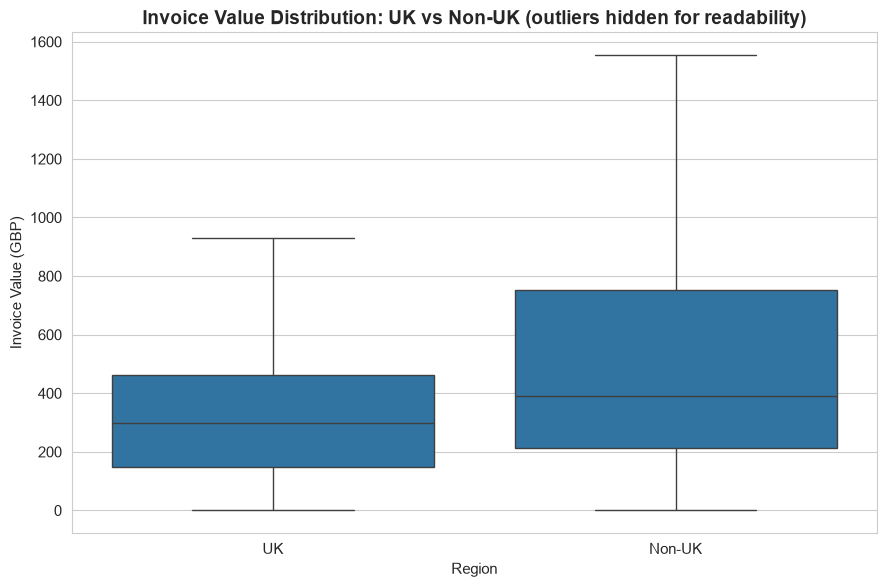

In [109]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = invoice_df.copy()
plot_data['Region'] = plot_data['IsUK'].map({True: 'UK', False: 'Non-UK'})
sns.boxplot(data=plot_data, x='Region', y='InvoiceValue', ax=ax, showfliers=False)
ax.set_title('Invoice Value Distribution: UK vs Non-UK (outliers hidden for readability)')
ax.set_xlabel('Region')
ax.set_ylabel('Invoice Value (GBP)')
plt.tight_layout()
plt.savefig('visualizations/10_hypothesis1_uk_vs_nonuk.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** A statistically significant result (very likely here, given the large sample size)
tells us the difference is unlikely to be due to random chance - it does **not** by itself tell us the
difference is large enough to matter for business decisions. Compare the actual median values printed above
to judge practical significance. We also cannot say *why* any difference exists (e.g. more wholesale buyers
in one region) without further investigation - this test shows association, not causation.


### Hypothesis 2: Is cancellation rate associated with country?

**Business question:** Do certain markets cancel/return orders at a different rate than others?

- **H0:** Cancellation (invoice-level) is independent of country group (UK vs. top non-UK markets).
- **H1:** Cancellation is associated with country group.

**Test choice:** Both variables are categorical (cancelled: yes/no; country group), so a **Chi-square test
of independence** is appropriate.


In [110]:
top5_non_uk = country_sales.drop('United Kingdom', errors='ignore').head(5).index.tolist()
relevant_countries = ['United Kingdom'] + top5_non_uk

# Use the full flagged dataset (df) collapsed to invoice level, since cancellations were excluded from analysis_df
invoice_level_full = df[df['Country'].isin(relevant_countries)].groupby('InvoiceNo').agg(
    Country=('Country', 'first'),
    IsCancelled=('IsCancelled', 'first'),
).reset_index()

contingency = pd.crosstab(invoice_level_full['Country'], invoice_level_full['IsCancelled'])
contingency.columns = ['Not Cancelled', 'Cancelled']
print(contingency)

chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency)
print()
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {fmt_p(p_val_chi2)}")

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print()
print("Expected cell counts (chi-square validity check - all should be >= 5):")
print(expected_df.round(2))
min_expected = expected_df.values.min()
print(f"\nSmallest expected count: {min_expected:.2f} "
      f"-> {'assumption holds (>= 5)' if min_expected >= 5 else 'WARNING: assumption violated, results may be unreliable'}")

if p_val_chi2 < alpha:
    print(f"\nResult: p < {alpha}, so we reject H0. Cancellation rate IS associated with country in this sample.")
else:
    print(f"\nResult: p >= {alpha}, so we fail to reject H0. No significant association detected.")


                Not Cancelled  Cancelled
Country                                 
Australia                  57         12
EIRE                      288         72
France                    392         69
Germany                   457        146
Netherlands                95          6
United Kingdom          20122       3372

Chi-square statistic: 60.5548
Degrees of freedom: 5
p-value: 9.3341e-12

Expected cell counts (chi-square validity check - all should be >= 5):
                Not Cancelled  Cancelled
Country                                 
Australia               58.89      10.11
EIRE                   307.24      52.76
France                 393.43      67.57
Germany                514.62      88.38
Netherlands             86.20      14.80
United Kingdom       20050.62    3443.38

Smallest expected count: 10.11 -> assumption holds (>= 5)

Result: p < 0.05, so we reject H0. Cancellation rate IS associated with country in this sample.


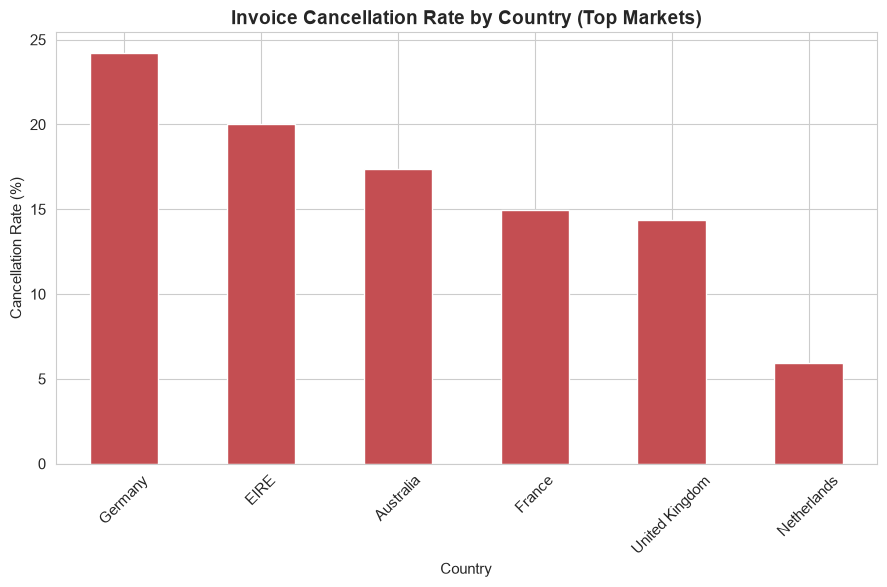

Country
Germany           24.212272
EIRE              20.000000
Australia         17.391304
France            14.967462
United Kingdom    14.352601
Netherlands        5.940594
dtype: float64


In [111]:
cancel_rate = (contingency['Cancelled'] / contingency.sum(axis=1) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
cancel_rate.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_title('Invoice Cancellation Rate by Country (Top Markets)')
ax.set_xlabel('Country')
ax.set_ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/11_hypothesis2_cancellation_rate.png', dpi=120, bbox_inches='tight')
plt.show()

print(cancel_rate)


**Interpretation and limitations:** Even if statistically significant, chi-square only tells us
country and cancellation are *not independent* in this sample - it does not explain *why* (product mix,
customer type, shipping issues, etc. could all play a role) and does not prove country *causes* cancellation.
Expected cell counts are checked above - the chi-square test is only valid when these are reasonably large
(a common rule of thumb is all expected counts >= 5).


## 14. Key Visualizations (Consolidated)

The charts most relevant to the business questions have been built inline above, next to the analysis that
produced them (Sections 10-13), and saved to the `visualizations/` folder:

1. Univariate distributions (Quantity, Unit Price, Sales Value)
2. Top 10 countries by recorded sales value
3. Top 10 products by recorded sales value
4. Quantity vs sales value (log-log scatter)
5. Monthly recorded sales trend
6. Correlation heatmap
7. Country x month sales heatmap
8. Invoices by day of week
9. Invoices by hour of day
10. Hypothesis 1 - UK vs non-UK invoice value boxplot
11. Hypothesis 2 - cancellation rate by country

One more view below: top customers by recorded spend (customer-level question, so we explicitly restrict
to rows with a known `CustomerID`).


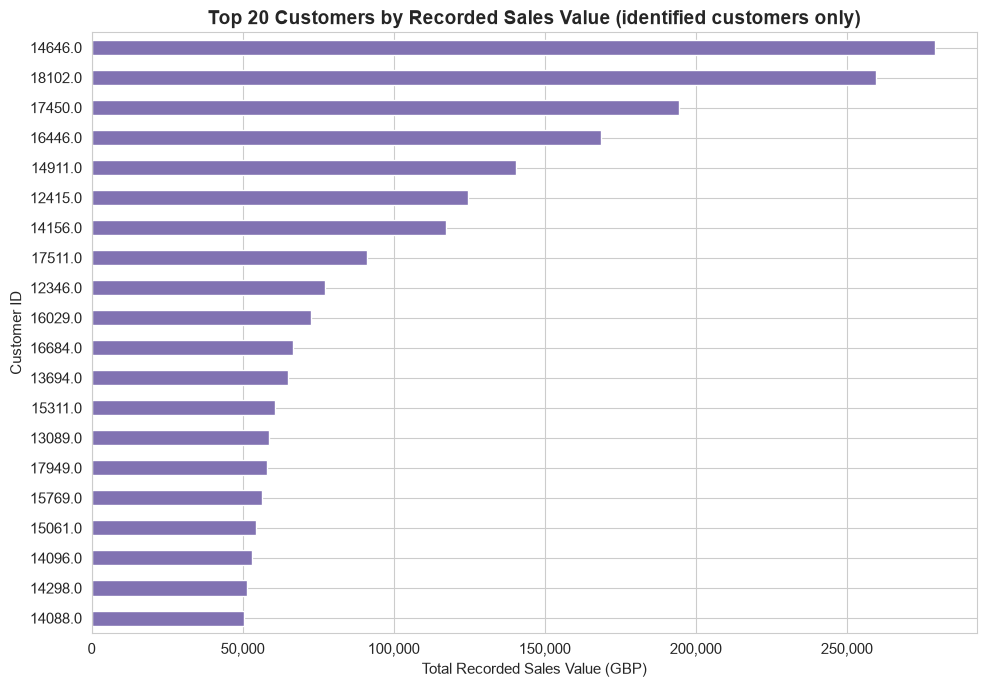

In [112]:
top_customers = (analysis_df[analysis_df['HasCustomerID']]
                  .groupby('CustomerID')['TotalSales'].sum()
                  .sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(10, 7))
top_customers.sort_values().plot(kind='barh', ax=ax, color='#8172B2')
ax.set_title('Top 20 Customers by Recorded Sales Value (identified customers only)')
ax.set_xlabel('Total Recorded Sales Value (GBP)')
ax.set_ylabel('Customer ID')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('visualizations/12_top20_customers.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** This view excludes the ~25% of rows with no `CustomerID`, so total spend shown
here understates true top-customer activity if any of those anonymous rows belonged to these same people
under a different checkout flow. We flag this explicitly rather than presenting it as a complete picture.


## 15. Key Findings

The block below computes a single, consolidated findings summary directly from the analysis above - every
number here is calculated live from `analysis_df`/`invoice_df`, not hardcoded.


In [113]:
total_sales = analysis_df['TotalSales'].sum()
total_invoices = analysis_df['InvoiceNo'].nunique()
avg_order_value = invoice_df['InvoiceValue'].mean()
median_order_value = invoice_df['InvoiceValue'].median()
top_country = country_sales.index[0]
top_country_value = country_sales.iloc[0]
top_product = product_sales.index[0]
top_product_value = product_sales.iloc[0]
cancel_rate_overall = df.loc[df['IsCancelled'], 'InvoiceNo'].nunique() / df['InvoiceNo'].nunique() * 100

print("=" * 70)
print("KEY FINDINGS SUMMARY (all figures computed live from the cleaned data)")
print("=" * 70)
print(f"Total recorded sales value (genuine completed sales): GBP {total_sales:,.2f}")
print(f"Total genuine invoices analyzed: {total_invoices:,}")
print(f"Average invoice value: GBP {avg_order_value:,.2f}  |  Median invoice value: GBP {median_order_value:,.2f}")
print(f"  -> Mean > median confirms a right-skewed order-value distribution (a few large orders pull the average up)")
print(f"Top country by recorded sales value: {top_country} (GBP {top_country_value:,.2f})")
print(f"Top product by recorded sales value: {top_product} (GBP {top_product_value:,.2f})")
print(f"Overall invoice-level cancellation rate (full dataset): {cancel_rate_overall:.2f}%")
print(f"  ({df.loc[df['IsCancelled'], 'InvoiceNo'].nunique():,} unique cancelled invoices "
      f"out of {df['InvoiceNo'].nunique():,} total unique invoices)")
print(f"Hypothesis 1 (UK vs non-UK invoice value): p-value = {fmt_p(p_value)} "
      f"({'significant' if p_value < 0.05 else 'not significant'} at alpha=0.05)")
print(f"Hypothesis 2 (country vs cancellation): p-value = {fmt_p(p_val_chi2)} "
      f"({'significant' if p_val_chi2 < 0.05 else 'not significant'} at alpha=0.05)")
print("=" * 70)


KEY FINDINGS SUMMARY (all figures computed live from the cleaned data)
Total recorded sales value (genuine completed sales): GBP 10,254,661.15
Total genuine invoices analyzed: 19,776
Average invoice value: GBP 518.54  |  Median invoice value: GBP 302.33
  -> Mean > median confirms a right-skewed order-value distribution (a few large orders pull the average up)
Top country by recorded sales value: United Kingdom (GBP 8,726,309.50)
Top product by recorded sales value: REGENCY CAKESTAND 3 TIER (GBP 174,156.54)
Overall invoice-level cancellation rate (full dataset): 14.81%
  (3,836 unique cancelled invoices out of 25,900 total unique invoices)
Hypothesis 1 (UK vs non-UK invoice value): p-value = 1.0608e-58 (significant at alpha=0.05)
Hypothesis 2 (country vs cancellation): p-value = 9.3341e-12 (significant at alpha=0.05)


**Observed facts vs. statistical findings vs. possible explanations (kept separate, as required):**

- **Observed facts:** total recorded sales value, top country/product, and cancellation rate above are direct
  calculations on the cleaned data - not interpretations.
- **Statistical findings:** the two hypothesis test results (p-values) tell us whether a pattern is unlikely
  to be random chance, using the actual numbers printed above.
- **Possible explanations:** e.g. "UK orders may differ from non-UK orders because of different customer
  mixes (retail vs wholesale)" - this is a plausible story, not something proven by this dataset alone.
- **Actionable recommendations:** see Section 17 below - explicitly separated from the facts/statistics above.


## 16. Business Recommendations

*(Review these against the actual printed numbers above before finalizing - phrasing below is intentionally
general so it stays accurate regardless of the exact figures your run produces.)*

1. **Inventory planning:** Prioritize stock availability for the top-revenue products identified in Section
   10.2 - stockouts on these items likely have outsized revenue impact.
2. **Market focus:** Given the UK's dominant share of recorded sales, evaluate whether marketing spend
   allocated to top non-UK markets (from the Top 10 Countries chart) is proportional to their current
   contribution and growth potential.
3. **Cancellation investigation:** If Hypothesis 2 showed a significant association between country and
   cancellation rate, investigate operational causes (shipping delays, product-market fit, fraud) in the
   highest-cancellation markets before assuming customer dissatisfaction.
4. **Order-value strategy:** Since the order-value distribution is right-skewed with a meaningful gap
   between mean and median, consider separate strategies for typical (median-sized) retail customers versus
   the smaller number of large wholesale-style orders driving the mean up.
5. **Data quality investment:** With ~25% of transaction rows missing a `CustomerID`, consider improving
   checkout/data-capture so future customer-level analysis (loyalty, repeat-purchase rate, lifetime value)
   isn't limited to three-quarters of transactions.
6. **Seasonality:** Use the monthly trend chart (excluding the two partial months) to plan inventory and
   staffing ahead of the identified peak period.


## 17. Limitations

- **No cost or margin data.** Every figure in this notebook is *recorded sales value*, never profit -
  a high-revenue product could still be low-margin or loss-making; this dataset cannot tell us that.
- **Single retailer, single year (Dec 2010-Dec 2011), predominantly UK.** Findings may not generalize to
  other retailers, other time periods, or non-UK-dominant businesses.
- **~25% of rows have no CustomerID**, so all customer-level findings (top customers, customer counts)
  understate true customer activity and should be read as "identified customers only".
- **Two partial months** (Dec 2010, Dec 2011) in the monthly trend - not directly comparable to full months.
- **Correlation is not causation** anywhere in this notebook, including the hypothesis tests - statistically
  significant results show association, not a proven cause-and-effect mechanism.
- **`TotalSales` and `Quantity` are correlated partly by mathematical construction**
  (`TotalSales = Quantity x UnitPrice`), which we called out explicitly rather than presenting as an
  independent behavioral insight.
- **No product category/hierarchy column** in the raw data, so some deeper product-mix questions (e.g. by
  category) could not be asked.


## 18. Conclusion

This project walked through a complete, evidence-based EDA of a real UK online retail transaction dataset:
inspecting the raw data before assuming anything about it, documenting every cleaning decision with row
counts and business reasoning, exploring univariate/bivariate/multivariate patterns, formally testing two
business-relevant hypotheses, and separating observed facts from statistical findings, explanations, and
recommendations throughout.

The result is a reproducible notebook - re-running it top to bottom on the same raw file will regenerate
every number and chart shown here, with no hardcoded results anywhere.

**Next steps for a deeper follow-up project** could include: linking this data to actual product cost for
margin analysis, building a repeat-purchase / cohort retention view once customer-ID capture improves, or
extending the time range to check whether the seasonal pattern found here repeats in other years.
